# Implementation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

# !pip install torchvision
import torchvision

import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# !pip install torchmetrics
import torchmetrics

Load dataset preloaded in `torchvision`

In [2]:
batch_size = 60

train_dataset = datasets.MNIST(root="dataset/", download=True, train=True, transform=transforms.ToTensor())

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = datasets.MNIST(root="dataset/", download=True, train=False, transform=transforms.ToTensor())

test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

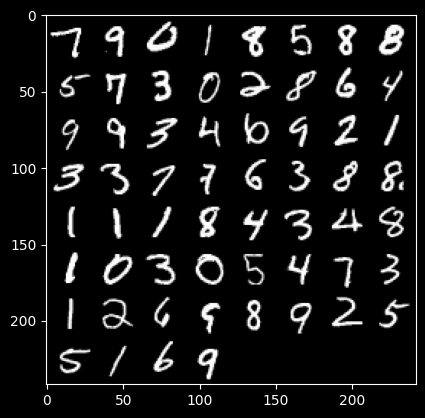

In [3]:
def imshow(img):
   npimg = img.numpy()
   plt.imshow(np.transpose(npimg, (1, 2, 0)))
   plt.show()

# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
labels
# show images
imshow(torchvision.utils.make_grid(images))

## Define the CNN architecture

We use the `torch.nn` (neural network) module

In [4]:

class CNN(nn.Module):
   def __init__(self, in_channels, num_classes):

       """
       Building blocks of convolutional neural network for a
       CNN with two convolutional layers, followed by a fully connected layer.

       Parameters:
           * in_channels: Number of channels in the input image (for grayscale images, 1)
           * num_classes: Number of classes to predict. In our problem, 10 (i.e digits from  0 to 9).
       """
       super(CNN, self).__init__()

       # 1st convolutional layer
       self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1)
       # Max pooling layer
       self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
       # 2nd convolutional layer
       self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
       # Fully connected layer
       self.fc1 = nn.Linear(16 * 7 * 7, num_classes)

   def forward(self, x):
       """
       Define the forward pass of the neural network.

       Parameters:
           x: Input tensor.

       Returns:
           torch.Tensor
               The output tensor after passing through the network.
       """
       x = F.relu(self.conv1(x))  # Apply first convolution and ReLU activation
       x = self.pool(x)           # Apply max pooling
       x = F.relu(self.conv2(x))  # Apply second convolution and ReLU activation
       x = self.pool(x)           # Apply max pooling
       x = x.reshape(x.shape[0], -1)  # Flatten the tensor
       x = self.fc1(x)            # Apply fully connected layer
       return x
       x = x.reshape(x.shape[0], -1)  # Flatten the tensor
       x = self.fc1(x)            # Apply fully connected layer
       return x

Now we can define the model

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNN(in_channels=1, num_classes=10).to(device)
print(model)

CNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=784, out_features=10, bias=True)
)


## Training the model
Since we are dealing with a multi-class classification problem, we will use the cross-entropy loss function, available in PyTorch as `nn.CrossEntropyLoss`. We will also use Adam optimizer, one of the most popular optimization algorithms.

In [6]:
# Define the loss function
cross_en_loss = nn.CrossEntropyLoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

We will iterate over ten epochs and training batches to train the model and perform the usual sequence of steps for each batch, as shown below.

In [7]:
num_epochs=10
for epoch in range(num_epochs):
 # Iterate over training batches
   print(f"Epoch [{epoch + 1}/{num_epochs}]")

   for batch_index, (data, targets) in enumerate(tqdm(train_loader)):
       data = data.to(device)
       targets = targets.to(device)
       scores = model(data)
       loss = cross_en_loss(scores, targets)
       optimizer.zero_grad()
       loss.backward()
       optimizer.step()

Epoch [1/10]


100%|██████████| 1000/1000 [00:05<00:00, 168.65it/s]


Epoch [2/10]


100%|██████████| 1000/1000 [00:05<00:00, 175.38it/s]


Epoch [3/10]


...

100%|██████████| 1000/1000 [00:14<00:00, 68.90it/s]


Epoch [9/10]


100%|██████████| 1000/1000 [00:05<00:00, 171.95it/s]


Epoch [10/10]


100%|██████████| 1000/1000 [00:05<00:00, 170.43it/s]


## Evaluating the model

Once the model is trained, we can evaluate its performance on the test dataset. We will use accuracy, a popular metric for classification problems. Accuracy measures the proportion of correctly classified cases from the total number of objects in the dataset. It’s calculated by dividing the number of correct predictions by the total number of predictions made by the model.

First, we set up the accuracy metric from `torchmetrics`. Next, we use the `.eval` method of the model to put the model in evaluation mode, because some layers in PyTorch models behave differently at training versus testing stages. We also add a Python context with torch.no_grad, indicating we will not be performing gradient calculation.

Then, we iterate over test examples with no gradient calculation. For each test batch, we get model outputs, take the most likely class, and pass it to the accuracy function along with the labels. Finally, we compute the metrics and print the results. We got a 0.98 accuracy score, which means that our model correctly classified 98% of the digits. Not bad!

In [8]:
from torchmetrics import Accuracy

acc       = Accuracy(task="multiclass", num_classes=10)

#puts the model in inference mode
#(network is actively analyzing new, unseen data to make predictions, rather than learning from data)
model.eval()
#no need to keep track of the gradient for the backward step
with torch.no_grad():
    for images, labels in test_loader:
        #forward pass, produces logits of shape [batch_size, 10]
        outputs = model(images)
        #argmax across the class dimension, giving the predicted class index per sample;
        # _ discards the actual max values
        _, preds = torch.max(outputs, 1)
        #each metric object accumulates the batch's true/false positive/negative counts internally,
        # no computation is anything yet
        acc(preds, labels)

test_accuracy  = acc.compute()


print(f"Test accuracy:  {test_accuracy:.4f}")


Test accuracy:  0.9862
